# ***libraries***


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ***Data preprocessing:***




In [14]:
train=pd.read_csv('Train (7).csv')

#droping columns:
train.drop('Employee ID',axis=1,inplace=True)

#we have in such a vars a nigative values so
train = train[(train['Years at Company'] > 0) & (train['Years at Company'] <= 100)]

# the log for num vars :
numerical_features = train.select_dtypes(include=np.number).columns
for col in numerical_features:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    train = train[(train[col] >= lower_bound) & (train[col] <= upper_bound)]
#droping duplicate rows:
train = train.drop_duplicates(keep='first')
#changine the '5' value to 'very high':
train['Job Satisfaction'] = train['Job Satisfaction'].replace("5", 'Very High')

# imputingg the 12 object missing values :
for col in train.select_dtypes(include='object').columns:
    train[col].fillna(train[col].mode()[0], inplace=True)

# Fill missing values in 'Age' with the mean
train['Age'].fillna(train['Age'].mean(), inplace=True)

# Fill missing values in numerical columns (except 'Age') with the median
for col in train.select_dtypes(include=np.number).columns:
    if col not in ['Age']:
        train[col].fillna(train[col].median(), inplace=True)

test=pd.read_csv('Test (7).csv')
#droping columns:
test.drop('Employee ID',axis=1,inplace=True)

#droping duplicate rows:
test = test.drop_duplicates(keep='first')

#changine the '5' value to 'very high':
test['Job Satisfaction'] = test['Job Satisfaction'].replace(5, 'Very High')

# imputomg the object missing values :
for col in test.select_dtypes(include='object').columns:
   test[col].fillna(test[col].mode()[0], inplace=True)

# Fill missing values in Age' with the mean
test['Age'].fillna(test['Age'].mean(), inplace=True)

# Fill missing values in numerical columns (except 'Age') with the median
for col in test.select_dtypes(include=np.number).columns:
    if col not in ['Age']:
        test[col].fillna(test[col].median(), inplace=True)

sample=pd.read_csv('Sample_Submission2 (1).csv')

<ipython-input-14-bd2954086b3a>:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)
<ipython-input-14-bd2954086b3a>:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

**Standarisation for monthly income :**

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train["Monthly Income"] = scaler.fit_transform(train[["Monthly Income"]])
test["Monthly Income"] = scaler.transform(test[["Monthly Income"]])

## ***Data visualisation, analysing defferent features:***

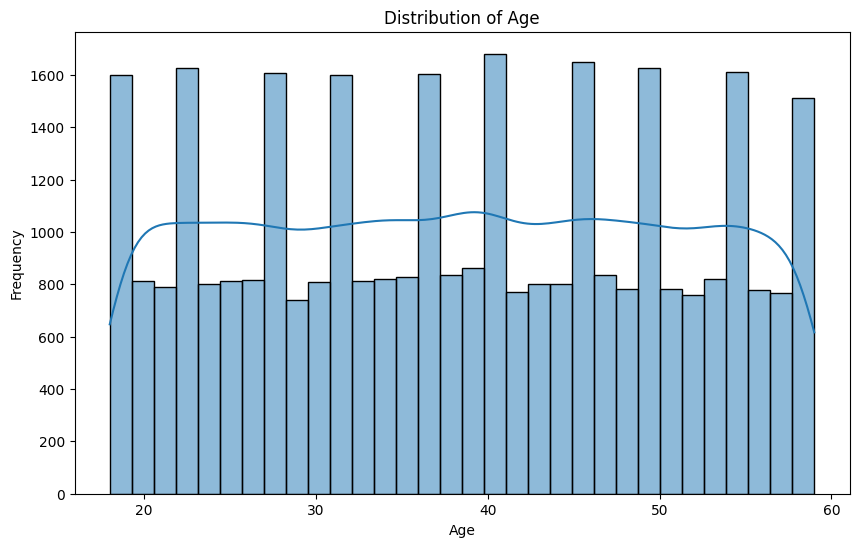

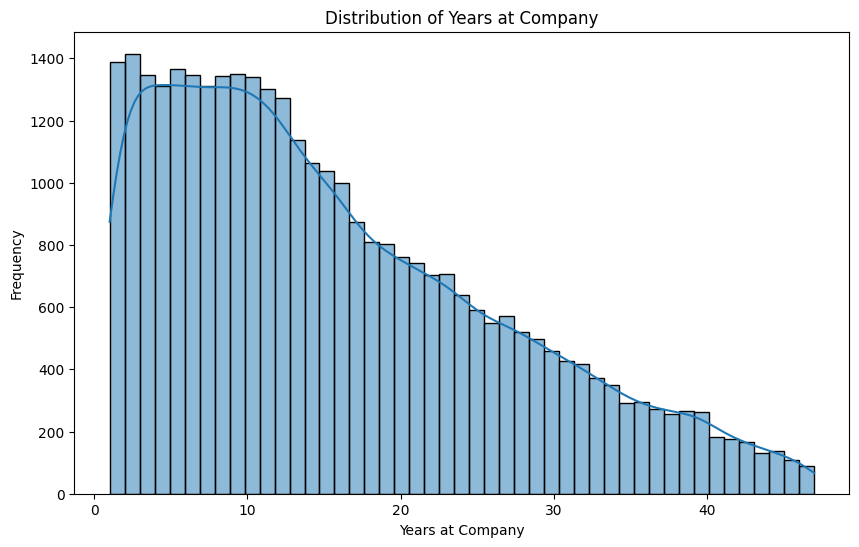

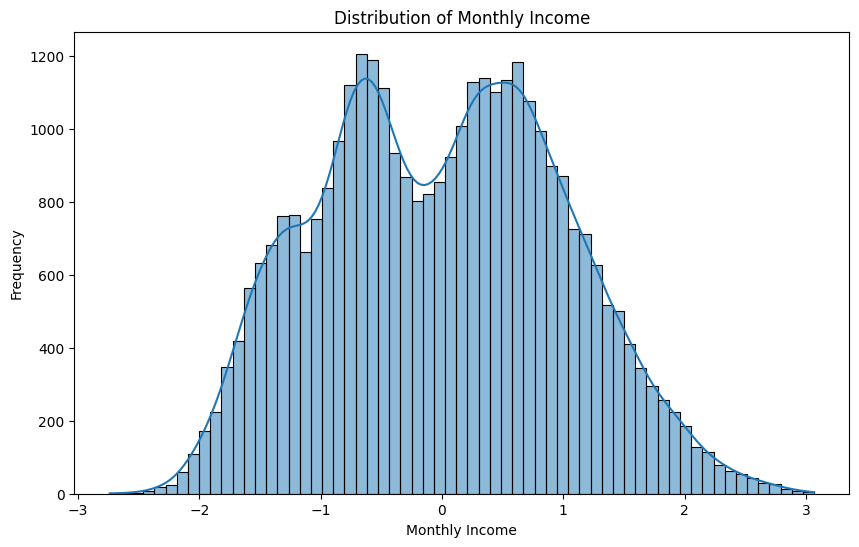

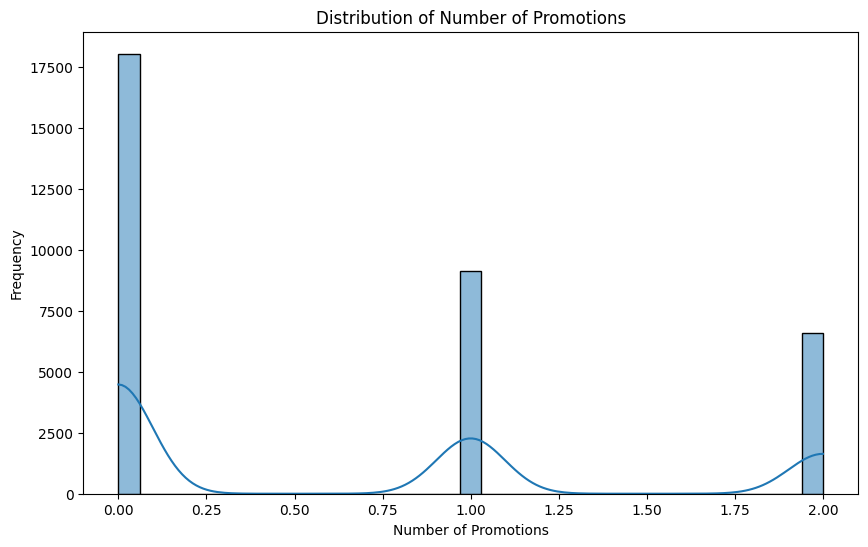

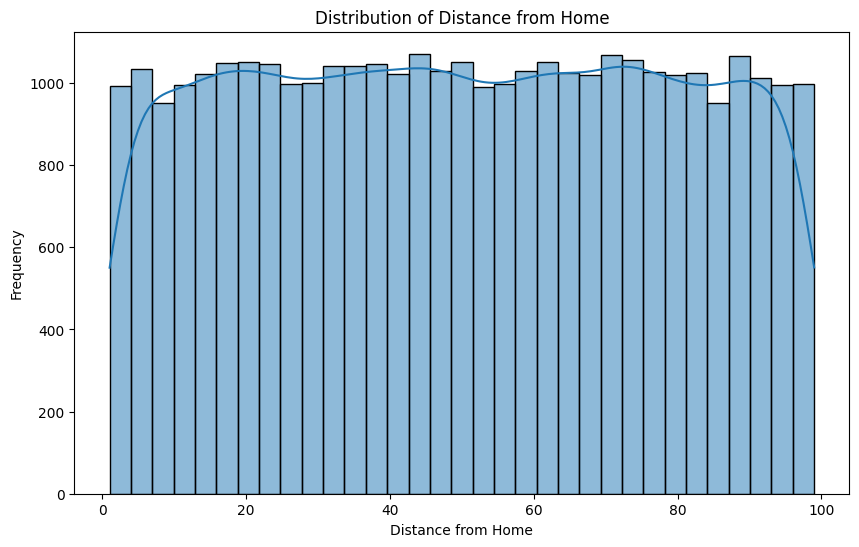

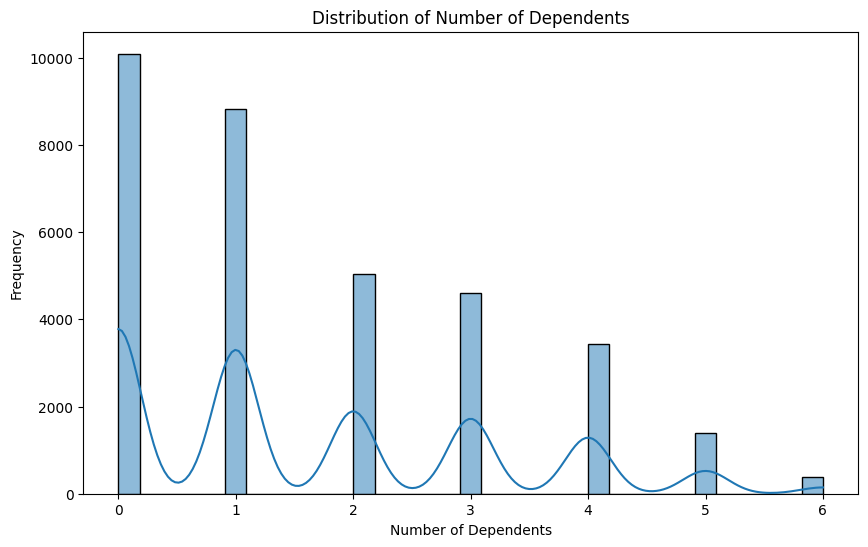

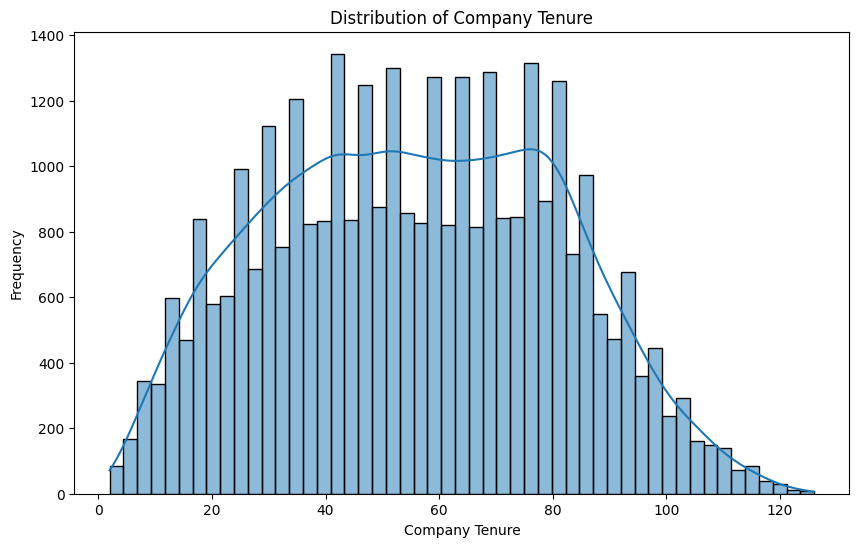

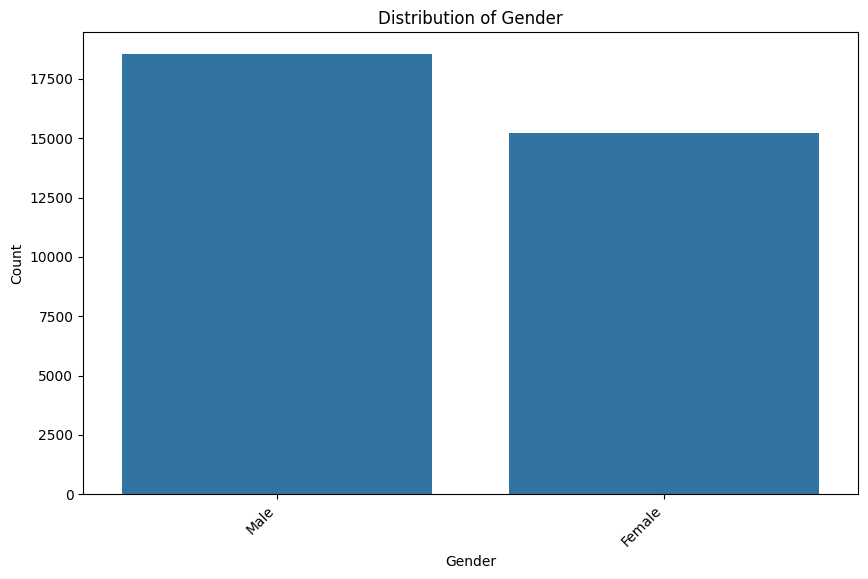

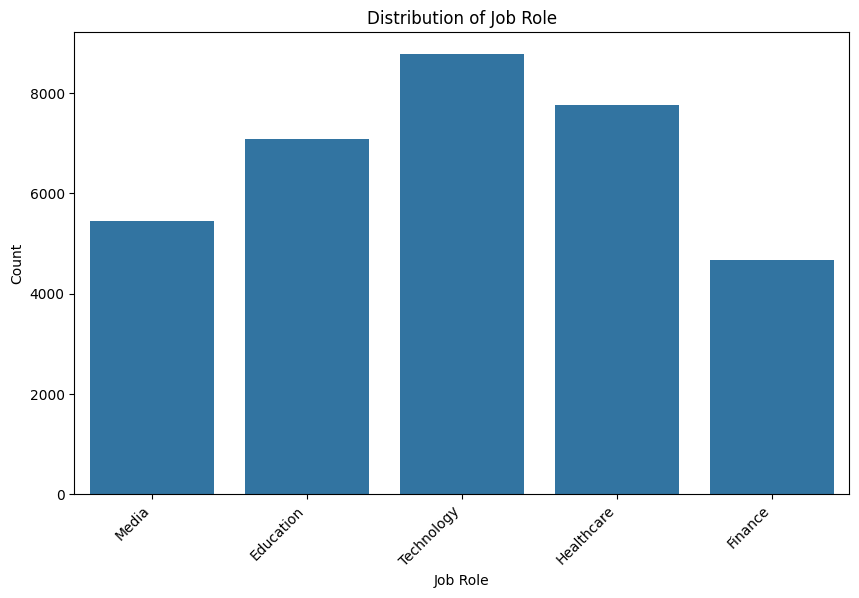

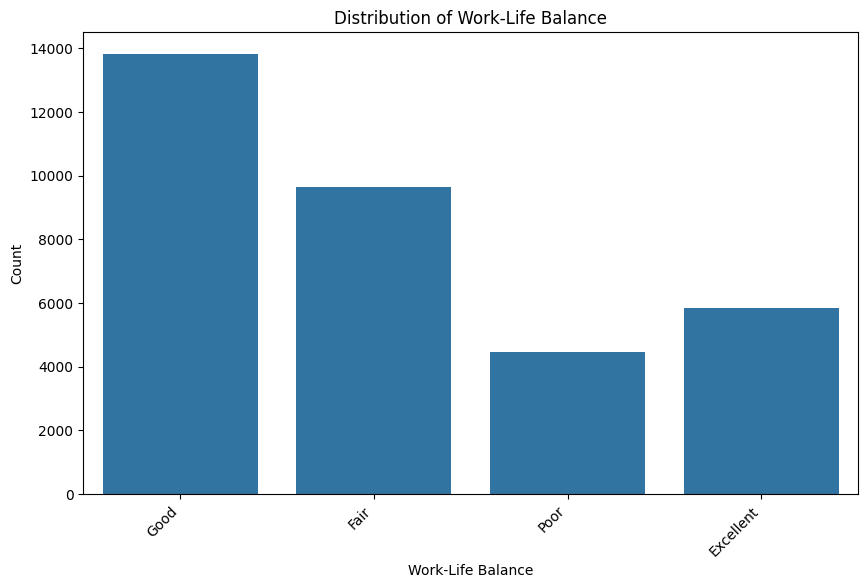

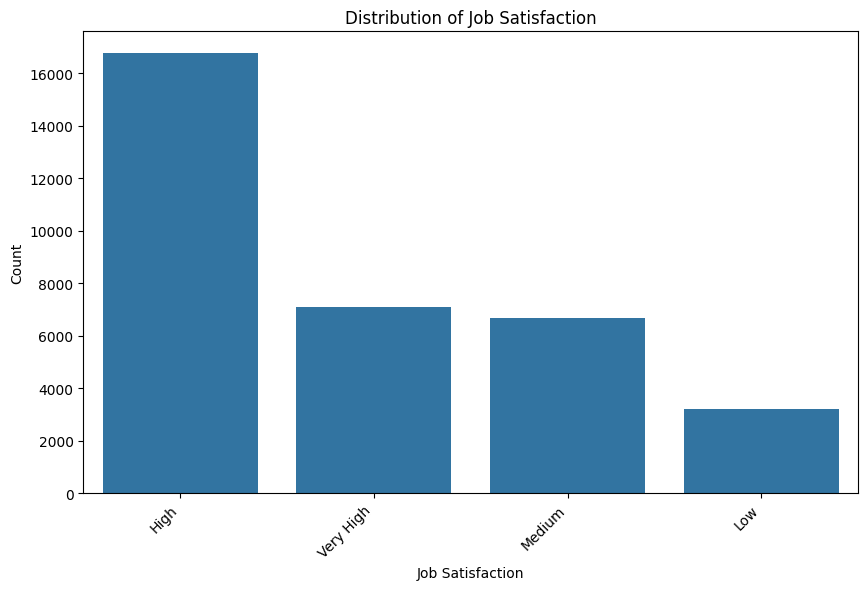

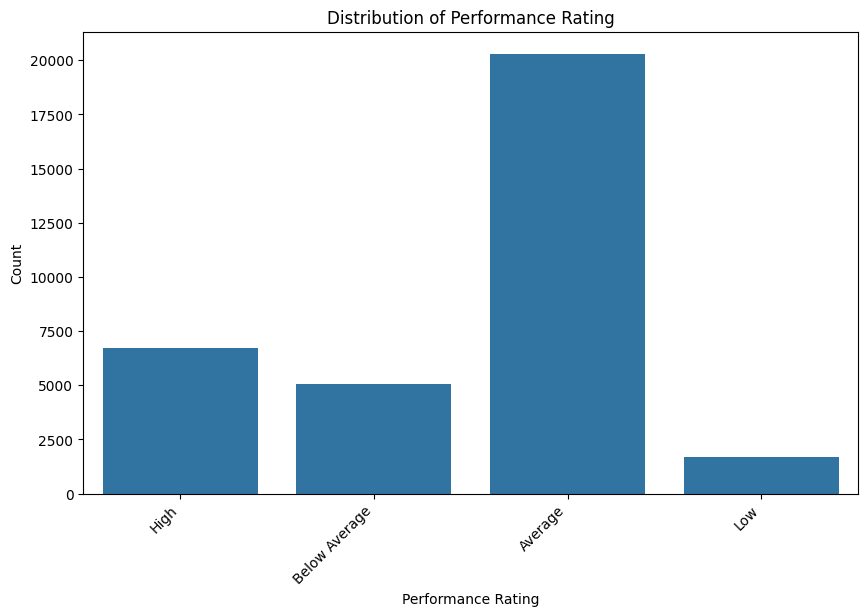

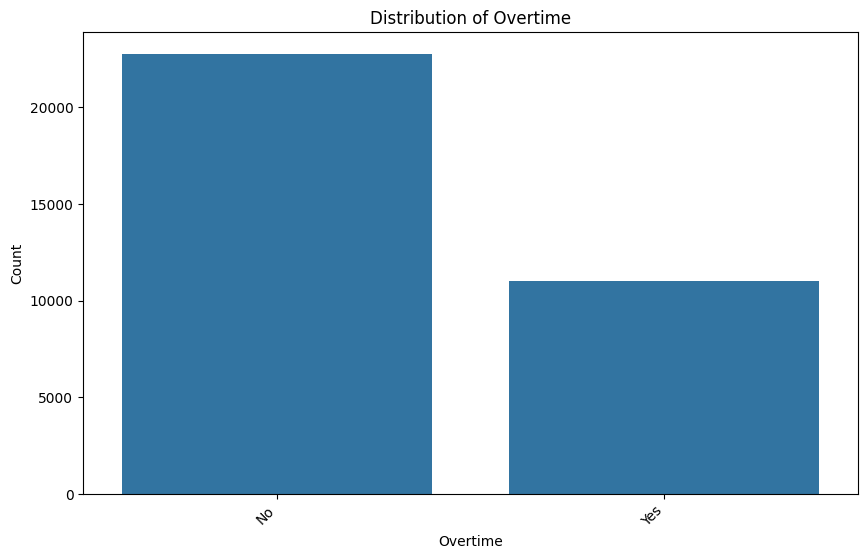

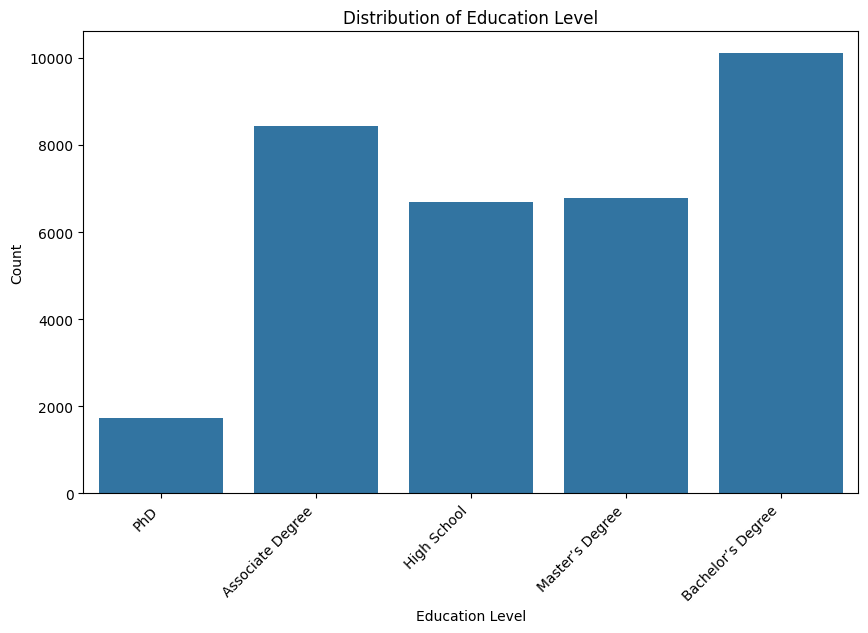

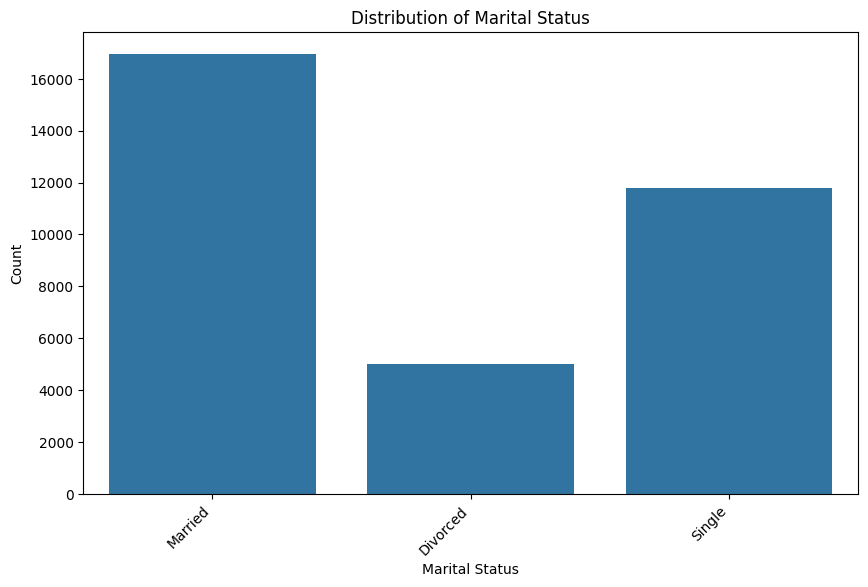

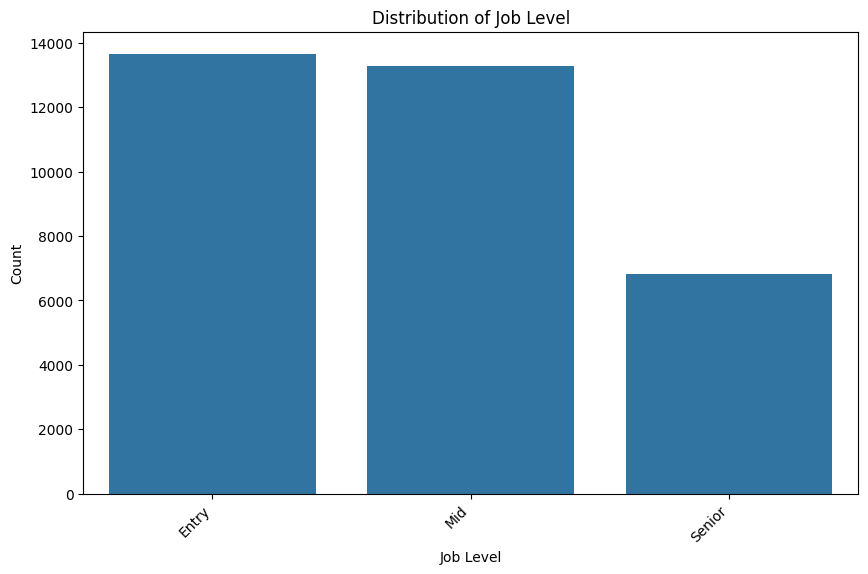

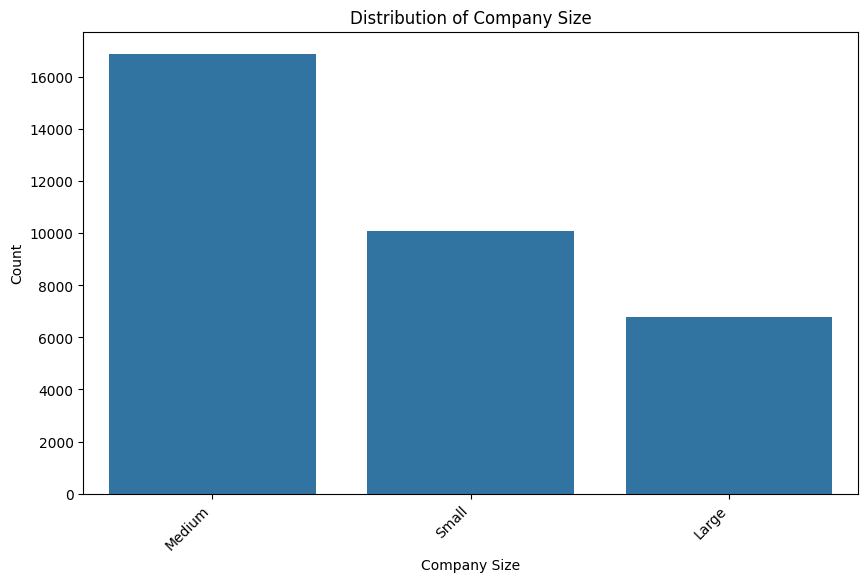

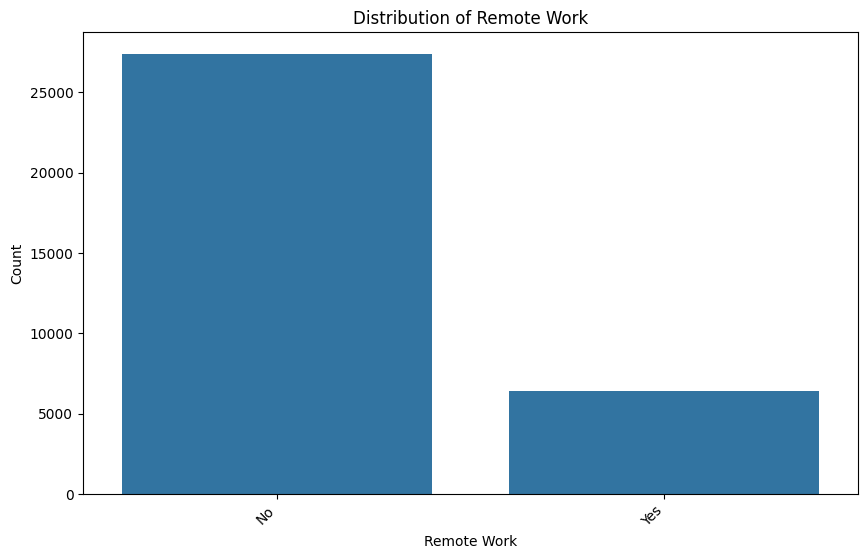

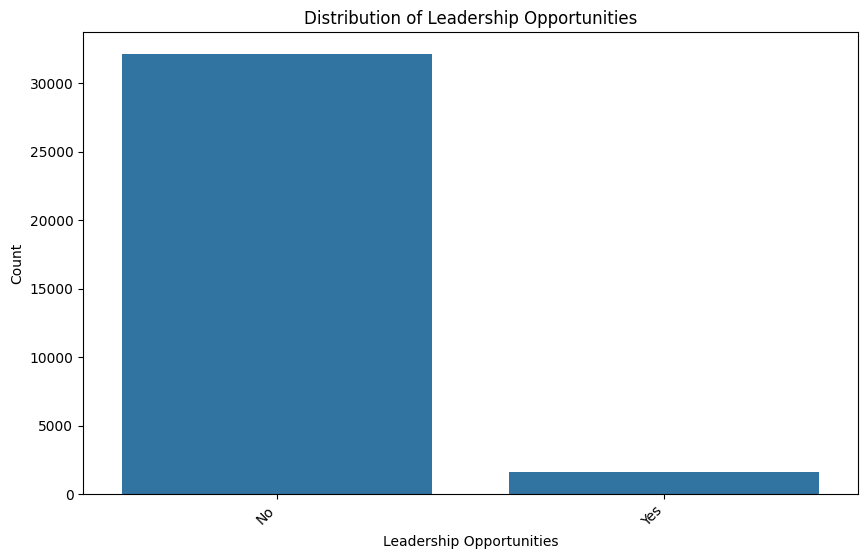

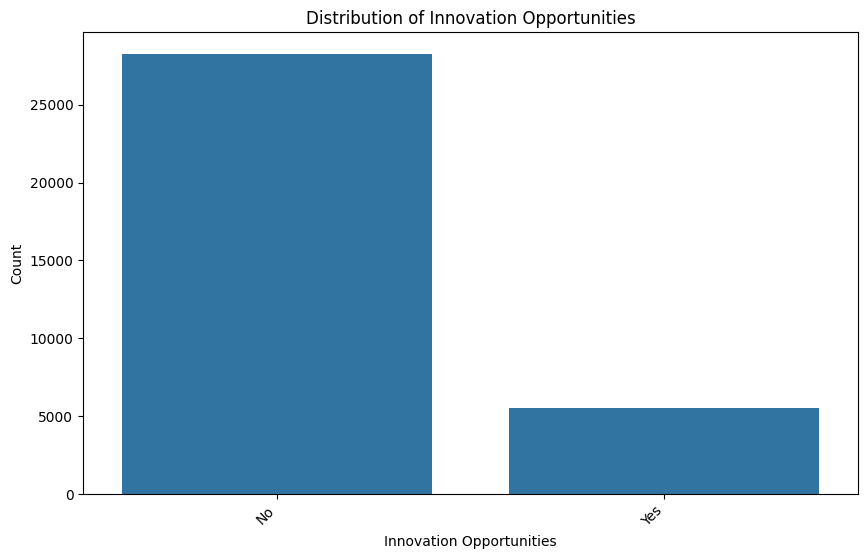

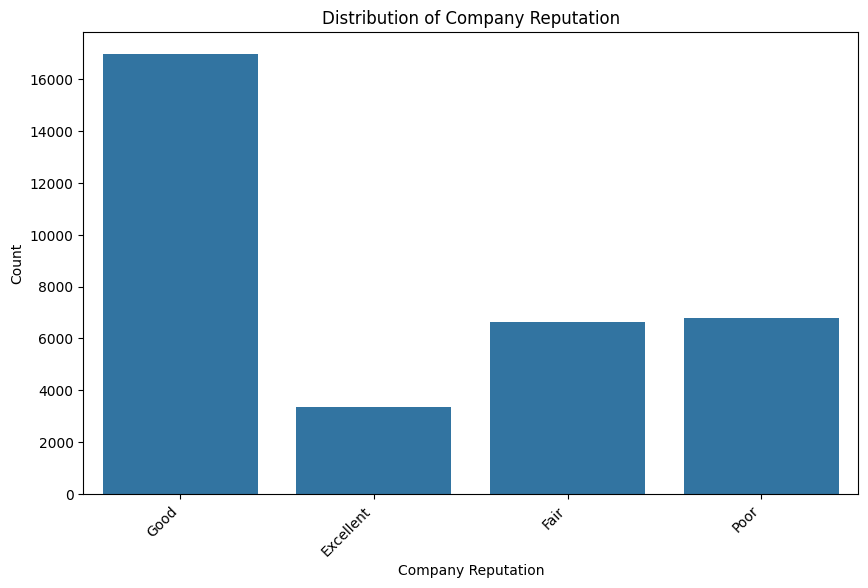

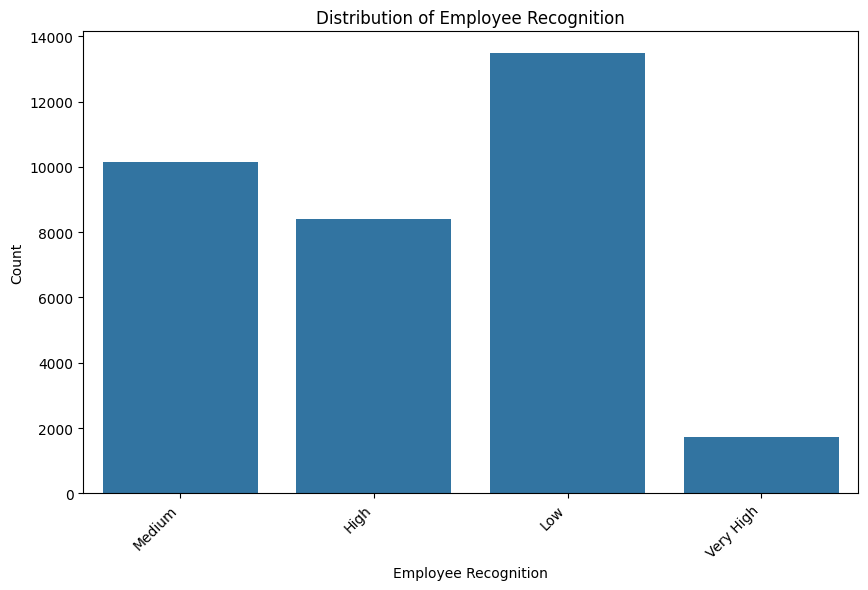

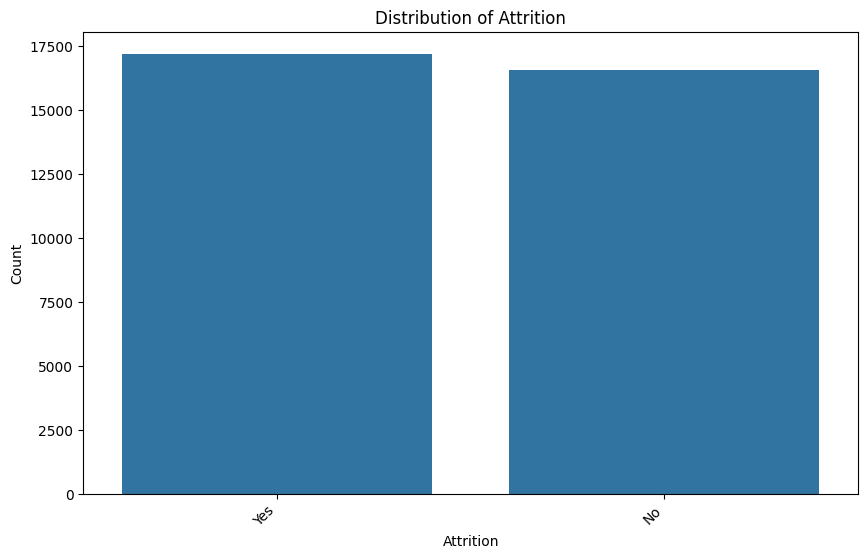

In [10]:
#for num vars
for col in train.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(train[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
#for cat vars
for col in train.select_dtypes(include='object').columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, data=train)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()

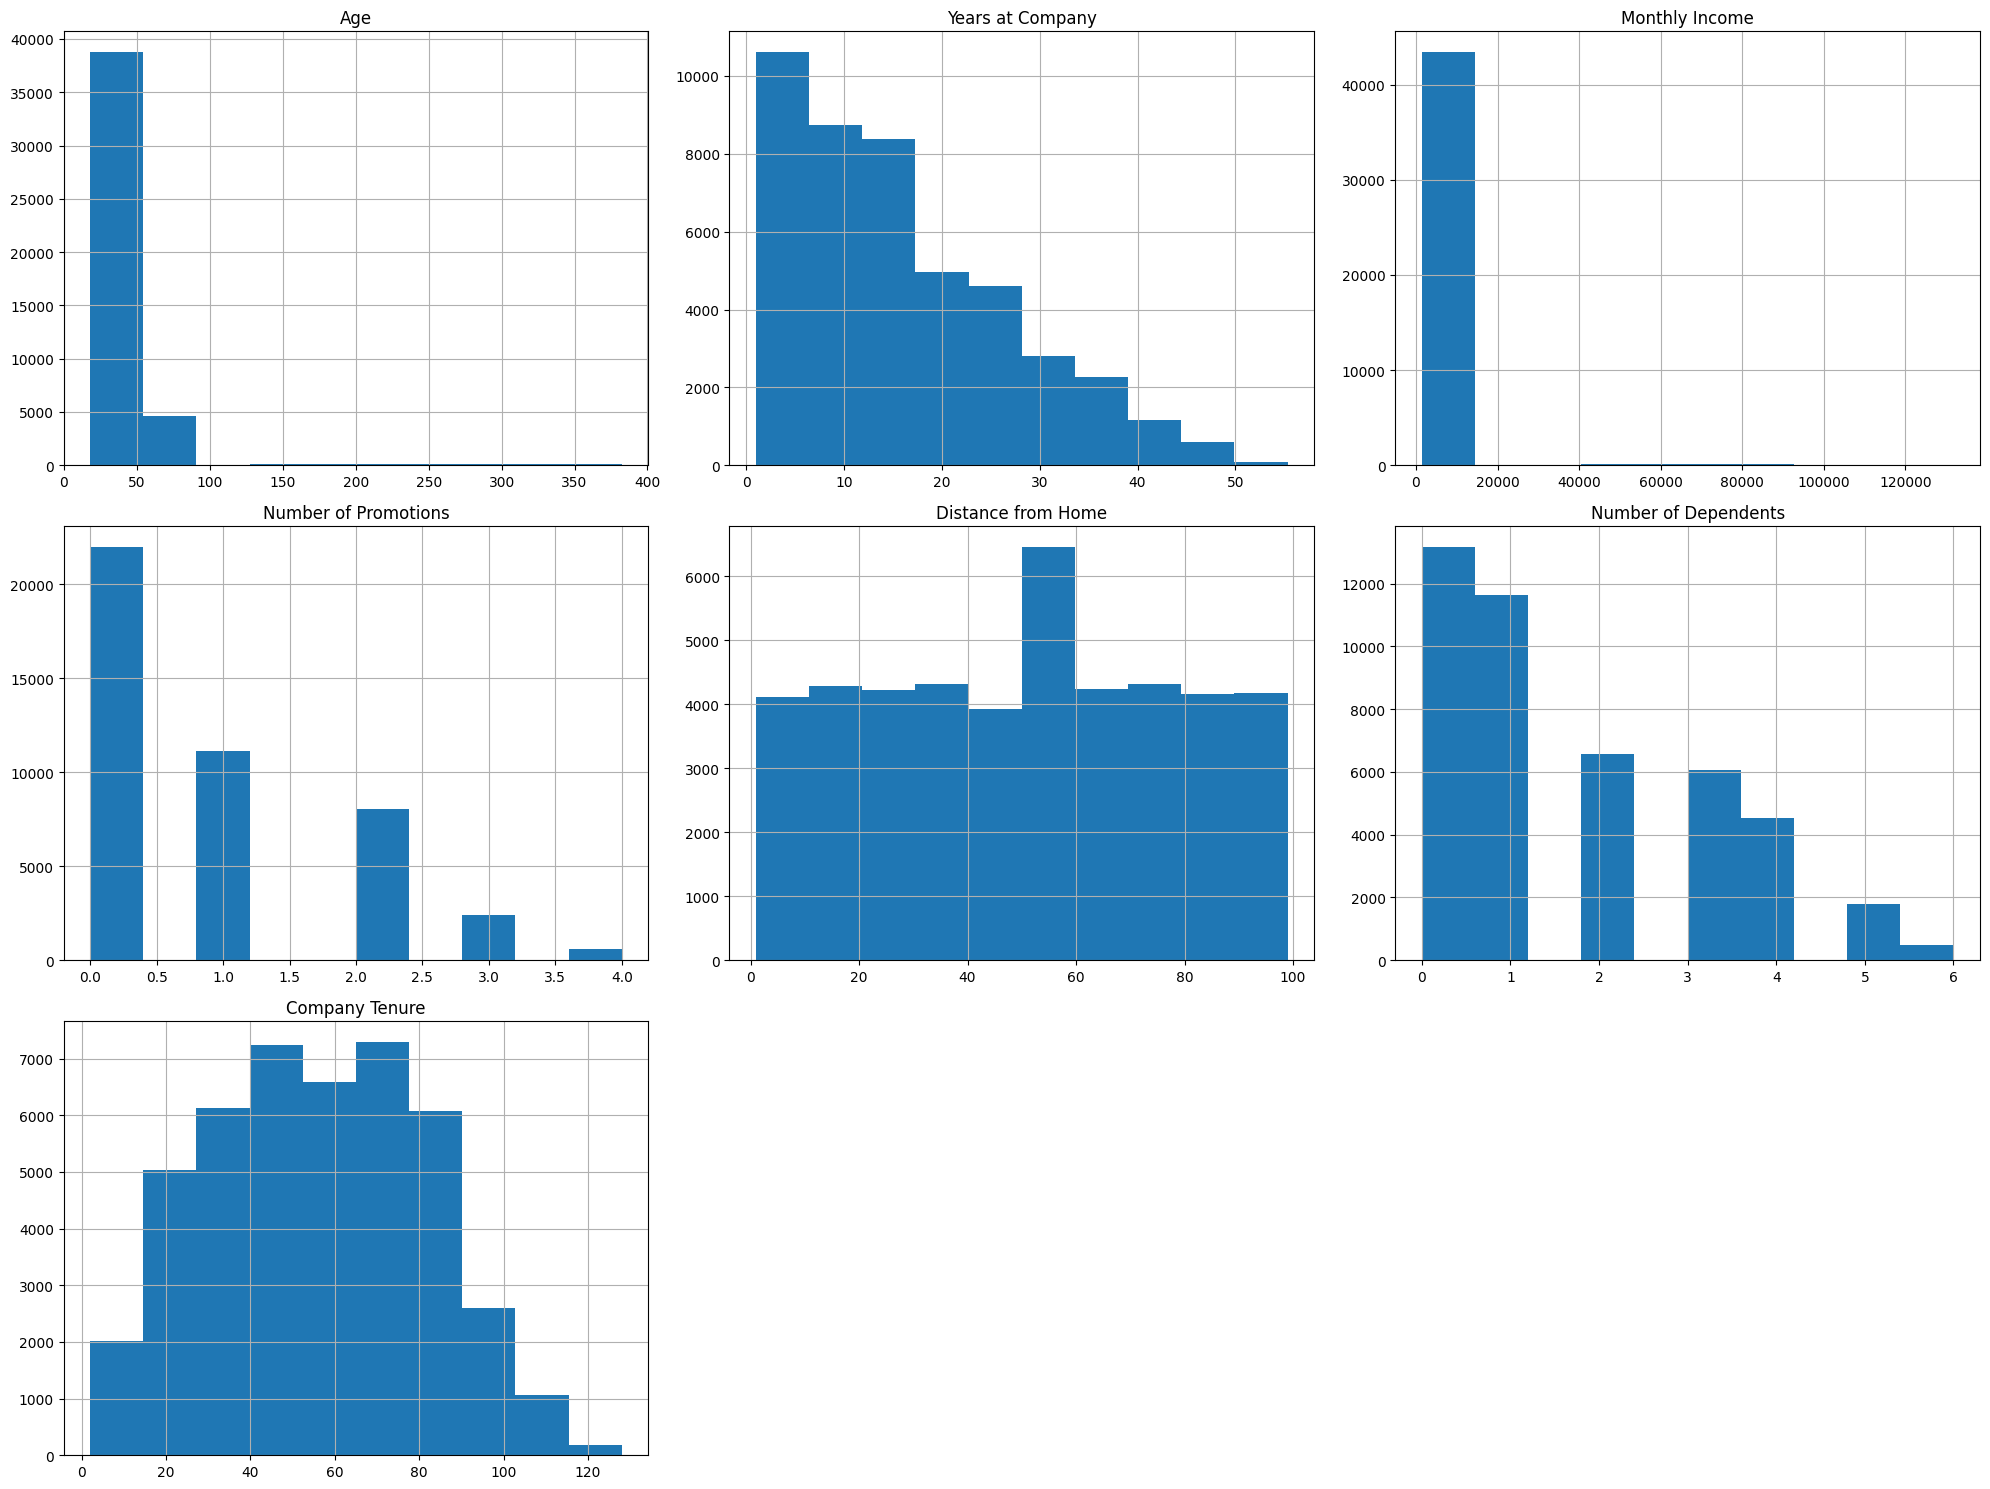

In [23]:
train.hist(figsize=(20, 15))
plt.tight_layout()
plt.show()

***using the label encoding:***


In [16]:
#the label encoding for the "Overtime" "Attrition" 'Gender' 'Attrition'   Company Tenure	Remote Work	Leadership Opportunities	Innovation Opportunities
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['Overtime'] = le.fit_transform(train['Overtime'])
train['Gender'] = le.fit_transform(train['Gender'])
train['Attrition'] = le.fit_transform(train['Attrition'])
train['Company Tenure'] = le.fit_transform(train['Company Tenure'])
train['Remote Work'] = le.fit_transform(train['Remote Work'])
train['Leadership Opportunities'] = le.fit_transform(train['Leadership Opportunities'])
train['Innovation Opportunities'] = le.fit_transform(train['Innovation Opportunities'])
test['Overtime'] = le.fit_transform(test['Overtime'])
test['Gender'] = le.fit_transform(test['Gender'])
test['Attrition'] = le.fit_transform(test['Attrition'])
test['Company Tenure'] = le.fit_transform(test['Company Tenure'])
test['Remote Work'] = le.fit_transform(test['Remote Work'])
test['Leadership Opportunities'] = le.fit_transform(test['Leadership Opportunities'])
test['Innovation Opportunities'] = le.fit_transform(test['Innovation Opportunities'])

***using the one hot encoding:***

In [17]:
#Work-Life Balance Job Satisfaction Performance Rating Education LevelCompany Reputation Job Level Employee Recognition
target = train["Years at Company"]
train = train.drop(columns=["Years at Company"], axis=1)
train = pd.get_dummies(train, columns=['Marital Status','Job Role',"Work-Life Balance","Job Satisfaction","Performance Rating","Education Level","Job Level","Company Size","Company Reputation","Employee Recognition"], drop_first=True)
test = pd.get_dummies(test, columns=['Marital Status','Job Role',"Work-Life Balance","Job Satisfaction","Performance Rating","Education Level","Job Level","Company Size","Company Reputation","Employee Recognition"], drop_first=True)
train_cols = train.columns
test_cols = test.columns
for col in train_cols:
    if col not in test_cols:
        test[col] = 0
for col in test_cols:
    if col not in train_cols:
        train[col] = 0
train = train[sorted(train.columns)]
test = test[sorted(test.columns)]
train["Years at Company"] = target

## **New features :**

In [ ]:
train["yearl_income"] = train["Monthly Income"] * 12
test["yearl_income"] = test["Monthly Income"] * 12

In [134]:
train['Income_vs_Job_Level'] = train['Monthly Income'] / train.groupby('Job Level_Mid')['Monthly Income'].transform('mean')
test['Income_vs_Job_Level'] = test['Monthly Income'] / test.groupby('Job Level_Mid')['Monthly Income'].transform('mean')

In [135]:
train['Remote_But_Far'] = (train['Remote Work'] == 1) & (train['Distance from Home'] > train['Distance from Home'].median())
test['Remote_But_Far'] = (test['Remote Work'] == 1) & (test['Distance from Home'] > test['Distance from Home'].median())

**corr between vars and the target var :**

In [125]:
numerical_features = train.select_dtypes(include=np.number).columns
correlation_matrix = train[numerical_features].corr()
years_at_company_correlation = correlation_matrix['Years at Company'].drop('Years at Company')
print(years_at_company_correlation)

Age                         0.288815
Attrition                   0.042143
Company Tenure              0.235360
Distance from Home         -0.006608
Gender                     -0.004247
Innovation Opportunities    0.006678
Leadership Opportunities    0.001152
Monthly Income             -0.009223
Number of Dependents        0.007454
Number of Promotions       -0.001575
Overtime                   -0.003735
Remote Work                -0.010021
Name: Years at Company, dtype: float64


# ***the modeling part:***



**1. lightgbm :**




In [25]:
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import mean_squared_error

# Define features (X) and target (y)
X = train.drop(columns=["Years at Company"])
y = train["Years at Company"]

# Define the LightGBM model
model = lgb.LGBMRegressor(
    n_estimators=1800,
    min_child_samples=39,
    max_depth=3,
    learning_rate=0.01,
    min_split_gain=5e-09
)
# Train the model
model.fit(X, y)

# Make predictions on the test set
predictions = model.predict(test)

submission = pd.DataFrame({
    'Employee ID': pd.read_csv('Sample_Submission2 (1).csv')['Employee ID'],
    'Years at Company': predictions
})
submission.to_csv('lgb.csv', index=False)
predictions


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 603
[LightGBM] [Info] Number of data points in the train set: 33760, number of used features: 41
[LightGBM] [Info] Start training from score 15.700375
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

array([11.79756473,  5.66923408, 10.95284072, ..., 26.26046365,
       12.62499135,  5.85493598])



**checking the best features:**



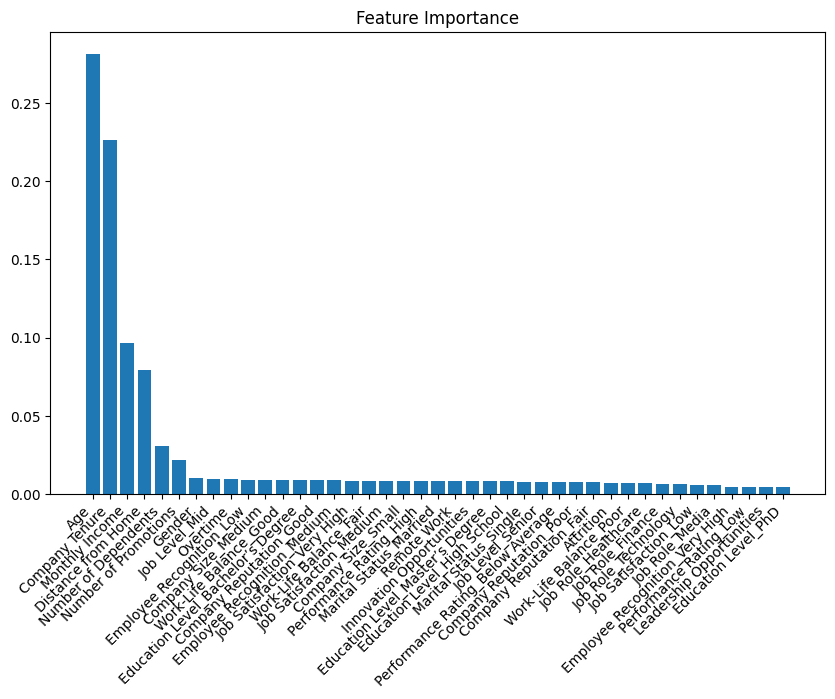

In [43]:
sorted_importance = dict(sorted(zip(model.feature_names_in_ , model.feature_importances_), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(10, 6))
plt.bar(sorted_importance.keys(),sorted_importance.values())
plt.xticks(rotation=45, ha="right")
plt.title('Feature Importance')
plt.show()


**checking the best parameters for lightgbm :**

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

param_space = {
    'n_estimators': Integer(500, 1500),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'min_child_samples': Integer(10, 50),
    'min_split_gain': Real(0, 1e-8),
}

model = lgb.LGBMRegressor()

bayes_search = BayesSearchCV(model, param_space, n_iter=20, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
bayes_search.fit(X, y)

print("Best parameters:", bayes_search.best_params_)